# kappa-bounded latent FT-NODE variants, via the `ftnode` package

Thin driver reproducing the two frozen notebooks

* `duffing_kappa_bounded_youla_skew_3variant_10seed.ipynb` (L-FT unbounded / SVD-clamp / Youla)
* `duffing_kappa_svdclamp_vs_ln_2variant_10seed.ipynb` (L-FT SVD-clamp vs unstructured L-N)

from one file. Those notebooks stay untouched as the 10-seed x 200-epoch record;
everything they defined inline now lives in `ftnode.systems`, `ftnode.latent`,
`ftnode.train` and `ftnode.diagnostics`, so this notebook is configuration plus
figures.

**What is being compared.** All variants share the latent form
`F(z,u) = A(z) (z - g(z,u))` and differ only in how `A(z)` is built:

| variant | `A(z)` | `kappa(A)` |
|---|---|---|
| `L-N` | none -- unstructured `MLP([z,u])`, parameter-matched | n/a |
| `L-FT (unbounded)` | `-(LL^T + sigma_min I) + (S - S^T)` | unbounded |
| `L-FT-k (SVD-clamp)` | `-(sigma_min I + P) + K`, both spectrally clamped | `<= kappa_max` |
| `L-FT-k (Youla)` | skew as `Q Sigma Q^T`, SVD-free | `<= kappa_max` |

The `QUICK` switch in the config cell trades run time for statistics: it defaults
to a reduced problem that finishes in minutes, and flipping it restores the frozen
notebooks' exact settings.

> **Stored outputs are from before the `operator`/`equilibrium` refactor.**
> The source below is current; the results shown were produced by the previous
> `LatentModelConfig` API. That refactor is numerically a no-op -- every value
> here was re-checked against it and reproduces exactly -- so the numbers stand,
> but source and output are not a matched pair until this notebook is re-executed.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from ftnode.systems import DuffingDataConfig, equilibria, make_dataset, sinks
from ftnode.latent import (KappaBudget, LatentModelConfig, EncoderConfig,
                           OperatorConfig, EquilibriumConfig,
                           build_clamp, build_youla, build_unbounded, build_latent_node)
from ftnode.train import TrainConfig, train_one, restore_best, rollout_y
from ftnode.diagnostics import (A_stats, skew_stats, eigvals_A, eig_field_jac,
                                pca_2d, linear_recovery_r2, g_image)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cpu


## Configuration

Every setting the frozen notebooks kept as loose module globals is now a frozen
dataclass.

`QUICK = True` runs a reduced problem -- fewer trajectories, shorter rollouts, 2
seeds -- so the notebook finishes in a few minutes on CPU. That is enough to
exercise the API and confirm the kappa bound holds, which is what this notebook
is for. `QUICK = False` restores the frozen notebooks' exact settings; budget
hours on CPU.

In [2]:
QUICK = True

if QUICK:
    SEEDS, N_EPOCHS = range(2), 15
    N_TRAJ, N_VAL   = 128, 32
    L_TRAIN, L_EVAL = 100, 300
else:                        # the frozen notebooks' settings
    SEEDS, N_EPOCHS = range(10), 200
    N_TRAJ, N_VAL   = 512, 64
    L_TRAIN, L_EVAL = 200, 600

budget    = KappaBudget(sigma_min=0.1, kappa_max=25.0, skew_frac=0.6, m=4)
model_cfg = LatentModelConfig(
    m=budget.m,
    encoder=EncoderConfig(z_scale=2.0, tau=8),
    operator=OperatorConfig(sigma_min=budget.sigma_min),
    equilibrium=EquilibriumConfig(R_g=2.0),
)
train_cfg = TrainConfig(n_epochs=N_EPOCHS, lr=3e-3, batch=64, clip=1.0, lam_res=1e-2,
                        L=L_TRAIN, L_eval=L_EVAL, h=0.05)

data_tr = DuffingDataConfig(n_traj=N_TRAJ, L=train_cfg.L,      tau=model_cfg.encoder.tau, seed=0)
data_va = DuffingDataConfig(n_traj=N_VAL,  L=train_cfg.L_eval, tau=model_cfg.encoder.tau, seed=1)

r_in = model_cfg.equilibrium.R_g * np.sqrt(budget.m)
print(f'budget = c_P + c_K = {budget.budget:.3f}   c_P = {budget.c_P:.3f}   c_K = {budget.c_K:.3f}')
print(f'sigma_max = {budget.sigma_max:.3f}   kappa <= {budget.kappa_max}   l_bound = {budget.l_bound:.4f}')
print(f'r_in = R_g*sqrt(m) = {r_in:.3f}   ->   certified R = kappa_max*r_in = {budget.kappa_max*r_in:.1f}')
print('open-loop sinks at u=0:', sinks(0.0))

budget = c_P + c_K = 2.400   c_P = 0.960   c_K = 1.440
sigma_max = 2.500   kappa <= 25.0   l_bound = 0.3098
r_in = R_g*sqrt(m) = 4.000   ->   certified R = kappa_max*r_in = 100.0
open-loop sinks at u=0: {'left': array([-1.,  0.]), 'right': array([1., 0.])}


## Data

Partial observation: only `y = q` is measured, so the identification problem is latent.

In [3]:
train = make_dataset(data_tr).to(device)
val   = make_dataset(data_va).to(device)
print('train window', tuple(train.W.shape), '| val window', tuple(val.W.shape),
      '| eval horizon', train_cfg.L_eval)

train window (128, 8) | val window (32, 8) | eval horizon 300


## Variant registry

One list of builders replaces the `MODEL_CONFIGS` dict-of-closures that both
frozen notebooks carried.

In [4]:
VARIANTS = [
    dict(name='L-N',                 kind='ln', color='C3', lam_res=0.0,
         build=lambda: build_latent_node(model_cfg)),
    dict(name='L-FT (unbounded)',    kind='ft', color='C1', lam_res=train_cfg.lam_res,
         build=lambda: build_unbounded(model_cfg, budget)),
    dict(name='L-FT-k (SVD-clamp)',  kind='ft', color='C0', lam_res=train_cfg.lam_res,
         build=lambda: build_clamp(model_cfg, budget)),
    dict(name='L-FT-k (Youla)',      kind='ft', color='C2', lam_res=train_cfg.lam_res,
         build=lambda: build_youla(model_cfg, budget)),
]
NAMES    = [v['name'] for v in VARIANTS]
FT_NAMES = [v['name'] for v in VARIANTS if v['kind'] == 'ft']
COLOR    = {v['name']: v['color'] for v in VARIANTS}
def slug(n): return n.replace('+','-').replace(' ','-').replace('(','').replace(')','').lower()

for v in VARIANTS:
    torch.manual_seed(0)
    n = sum(p.numel() for p in v['build']().dynamics.parameters())
    print(f"{v['name']:22s} dynamics params {n:,}")

L-N                    dynamics params 28,314
L-FT (unbounded)       dynamics params 27,934
L-FT-k (SVD-clamp)     dynamics params 28,324
L-FT-k (Youla)         dynamics params 36,704


### Sanity check before training

The kappa cap is structural, so it holds at initialization. Confirm that before
spending any epochs -- if it fails here, no amount of training will fix it.

In [5]:
Zbox = ((2 * torch.rand(4000, budget.m, generator=torch.Generator().manual_seed(0)) - 1)
        * model_cfg.encoder.z_scale).to(device)

print(f'{"variant":22s} {"kappa med":>10s} {"kappa max":>10s} {"||K||2 max":>11s}')
for v in VARIANTS:
    if v['kind'] != 'ft':
        print(f"{v['name']:22s}   (unstructured NODE - no A(z))"); continue
    torch.manual_seed(0)
    dyn = v['build']().to(device).dynamics.eval()
    _, _, kap = A_stats(dyn, Zbox)
    kn, _ = skew_stats(dyn, Zbox)
    print(f"{v['name']:22s} {np.median(kap):10.2f} {kap.max():10.2f} {kn.max():11.3f}")
print(f'\ntargets: kappa <= {budget.kappa_max}   ||K||_2 <= c_K = {budget.c_K:.3f}')

variant                 kappa med  kappa max  ||K||2 max
L-N                      (unstructured NODE - no A(z))
L-FT (unbounded)             1.53       1.70       0.000
L-FT-k (SVD-clamp)           1.55       2.20       0.000
L-FT-k (Youla)               7.59       7.73       0.765

targets: kappa <= 25.0   ||K||_2 <= c_K = 1.440


## Multi-seed training

The seed loop is deliberately left here rather than packaged: it is a dozen lines
and every experiment wants it slightly different.

In [6]:
histories = {n: [] for n in NAMES}
models    = {n: [] for n in NAMES}

for v in VARIANTS:
    cfg = TrainConfig(**{**train_cfg.__dict__, 'lam_res': v['lam_res']})
    for seed in SEEDS:
        torch.manual_seed(seed); np.random.seed(seed)
        model = v['build']().to(device)
        ckpt  = f"pkg-{slug(v['name'])}-seed{seed}.pth"
        model, hist = train_one(model, train, val, cfg, ckpt_path=ckpt,
                                label=f"{v['name']}-s{seed}", device=device, verbose=False)
        restore_best(model, hist, device, verbose=False)
        histories[v['name']].append(hist)
        models[v['name']].append(model)
        print(f"[{v['name']:22s} seed {seed}] best_val {hist['best_val']:.3e} "
              f"@ ep {hist['best_epoch']}  diverged={hist['diverged_at']}")

[L-N                    seed 0] best_val 7.338e-01 @ ep 14  diverged=None


[L-N                    seed 1] best_val 6.733e-01 @ ep 14  diverged=None


[L-FT (unbounded)       seed 0] best_val 7.403e-01 @ ep 14  diverged=None


[L-FT (unbounded)       seed 1] best_val 7.466e-01 @ ep 14  diverged=None


[L-FT-k (SVD-clamp)     seed 0] best_val 7.204e-01 @ ep 14  diverged=None


[L-FT-k (SVD-clamp)     seed 1] best_val 7.341e-01 @ ep 14  diverged=None


[L-FT-k (Youla)         seed 0] best_val 7.980e-01 @ ep 14  diverged=None


[L-FT-k (Youla)         seed 1] best_val 7.452e-01 @ ep 14  diverged=None


## D1 -- training and extrapolation curves

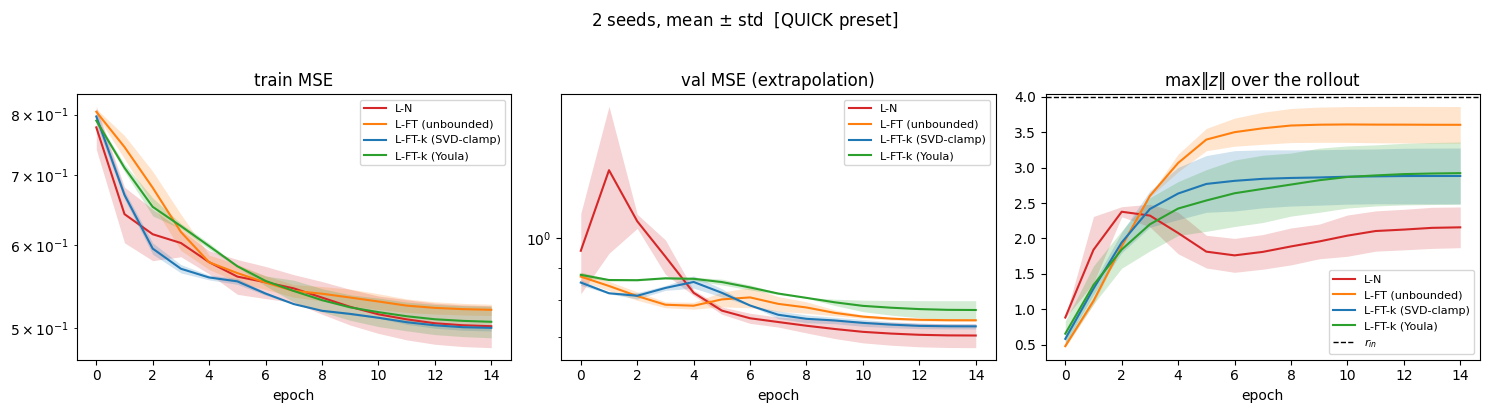

In [7]:
def band(ax, arr, color, label, logy=False):
    mu, sd = np.nanmean(arr, 0), np.nanstd(arr, 0)
    x = np.arange(arr.shape[1])
    ax.plot(x, mu, color=color, label=label)
    ax.fill_between(x, mu - sd, mu + sd, color=color, alpha=0.2, lw=0)
    if logy: ax.set_yscale('log')

def seed_grid(n, ncols=5, panel=(2.7, 2.4), **kw):
    ncols = min(ncols, n); nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(panel[0]*ncols, panel[1]*nrows), squeeze=False, **kw)
    axes = axes.ravel()
    for j in range(n, len(axes)): axes[j].axis('off')
    return fig, axes

def stack(name, key):
    rows = [h[key] for h in histories[name]]
    out = np.full((len(rows), N_EPOCHS), np.nan)
    for i, r in enumerate(rows): out[i, :len(r)] = r
    return out

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for name in NAMES:
    band(axes[0], stack(name, 'train'),      COLOR[name], name, logy=True)
    band(axes[1], stack(name, 'val_extrap'), COLOR[name], name, logy=True)
    band(axes[2], stack(name, 'zmax'),       COLOR[name], name)
axes[0].set_title('train MSE');            axes[0].set_xlabel('epoch')
axes[1].set_title('val MSE (extrapolation)'); axes[1].set_xlabel('epoch')
axes[2].set_title(r'$\max\|z\|$ over the rollout'); axes[2].set_xlabel('epoch')
axes[2].axhline(r_in, ls='--', c='k', lw=1, label=r'$r_{in}$')
for a in axes: a.legend(fontsize=8)
fig.suptitle(f'{len(list(SEEDS))} seeds, mean $\pm$ std' + ('  [QUICK preset]' if QUICK else ''), y=1.02)
fig.tight_layout(); plt.show()

## D2 -- best validation MSE by variant

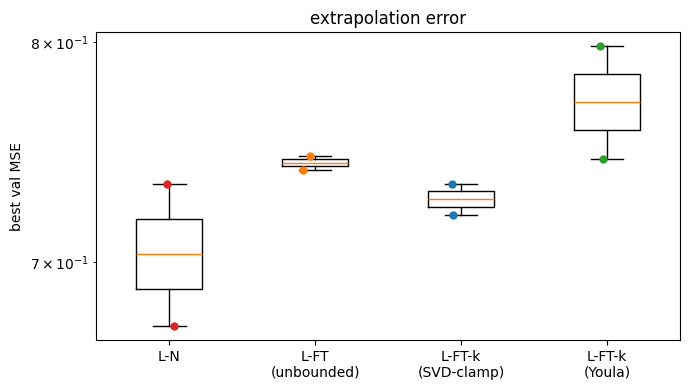

variant                      median          min   diverged
L-N                       7.035e-01    6.733e-01       0/2
L-FT (unbounded)          7.435e-01    7.403e-01       0/2
L-FT-k (SVD-clamp)        7.273e-01    7.204e-01       0/2
L-FT-k (Youla)            7.716e-01    7.452e-01       0/2


In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
vals = [[h['best_val'] for h in histories[n]] for n in NAMES]
bp = ax.boxplot(vals, tick_labels=[n.replace(' ', '\n') for n in NAMES], showfliers=False)
for i, (n, vv) in enumerate(zip(NAMES, vals), start=1):
    ax.scatter(np.full(len(vv), i) + np.random.uniform(-.08, .08, len(vv)), vv,
               color=COLOR[n], zorder=3, s=25)
ax.set_yscale('log'); ax.set_ylabel('best val MSE'); ax.set_title('extrapolation error')
fig.tight_layout(); plt.show()

print(f'{"variant":22s} {"median":>12s} {"min":>12s} {"diverged":>10s}')
for n, vv in zip(NAMES, vals):
    nd = sum(h['diverged_at'] is not None for h in histories[n])
    print(f'{n:22s} {np.median(vv):12.3e} {np.min(vv):12.3e} {nd:>7d}/{len(vv)}')

## K2 / K3 -- the kappa bound on trained models

**This is the headline figure.** For the two bounded variants the cap is imposed
by construction, so training cannot break it. `L-FT (unbounded)` is the control:
same stability structure, same residual regularizer, but nothing caps its skew
part -- so it is *free* to drift past `kappa_max`, and it does. The contrast is
the evidence that the constraint is doing work rather than being satisfied
incidentally.

variant                 kappa med  kappa max   vs kappa_max = 25.0
L-FT (unbounded)             4.61      34.17   exceeds cap, as expected (no bound imposed)
L-FT-k (SVD-clamp)           4.50      18.40   OK -- cap holds
L-FT-k (Youla)               7.49       8.92   OK -- cap holds


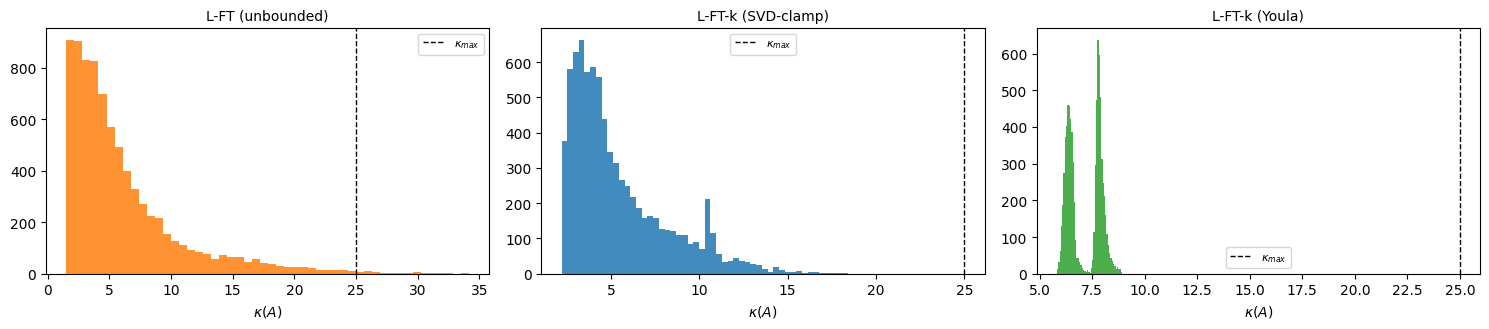

In [9]:
BOUNDED = {'L-FT-k (SVD-clamp)', 'L-FT-k (Youla)'}

kappa_by_name = {}
for name in FT_NAMES:
    kappa_by_name[name] = np.concatenate(
        [A_stats(mdl.dynamics.eval(), Zbox)[2] for mdl in models[name]])

print(f'{"variant":22s} {"kappa med":>10s} {"kappa max":>10s}   vs kappa_max = {budget.kappa_max}')
for n, k in kappa_by_name.items():
    if n in BOUNDED:
        verdict = ('OK -- cap holds' if k.max() <= budget.kappa_max + 1e-4
                   else 'FAIL -- structural bound broken!')
    else:
        verdict = ('exceeds cap, as expected (no bound imposed)'
                   if k.max() > budget.kappa_max else 'under cap by luck (no bound imposed)')
    print(f'{n:22s} {np.median(k):10.2f} {k.max():10.2f}   {verdict}')

fig, axes = plt.subplots(1, len(FT_NAMES), figsize=(5 * len(FT_NAMES), 3.4), squeeze=False)
for ax, n in zip(axes[0], FT_NAMES):
    ax.hist(kappa_by_name[n], bins=50, color=COLOR[n], alpha=.85)
    ax.axvline(budget.kappa_max, ls='--', c='k', lw=1, label=r'$\kappa_{max}$')
    ax.set_title(n, fontsize=10); ax.set_xlabel(r'$\kappa(A)$'); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

## K4 -- skew diagnostics: `||K||_2` against its budget `c_K`

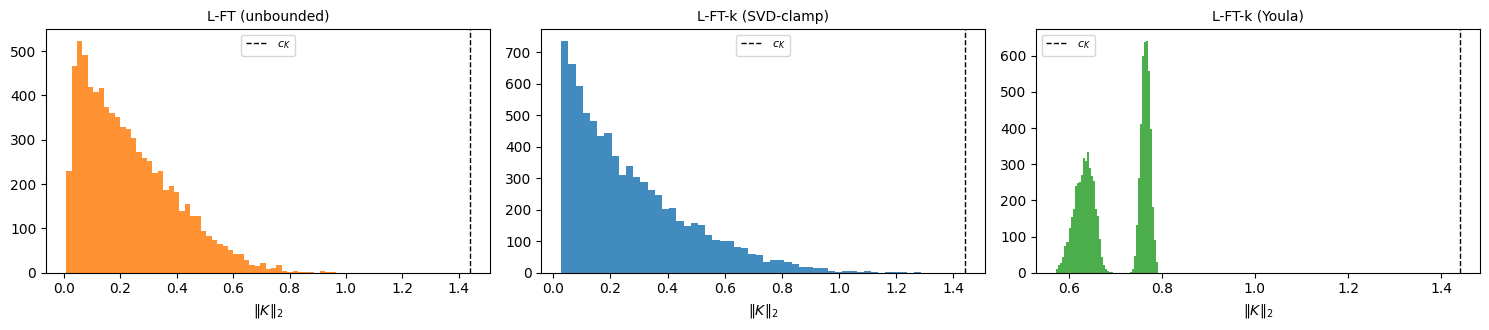

In [10]:
fig, axes = plt.subplots(1, len(FT_NAMES), figsize=(5 * len(FT_NAMES), 3.4), squeeze=False)
for ax, n in zip(axes[0], FT_NAMES):
    kn = np.concatenate([skew_stats(m.dynamics.eval(), Zbox)[0] for m in models[n]])
    ax.hist(kn, bins=50, color=COLOR[n], alpha=.85)
    ax.axvline(budget.c_K, ls='--', c='k', lw=1, label=r'$c_K$')
    ax.set_title(n, fontsize=10); ax.set_xlabel(r'$\|K\|_2$'); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

## K5 -- forward invariance

`max ||z||` over the rollout against the ball radius `r_in = R_g*sqrt(m)` and the
certified radius `R = kappa_max * r_in`. The bounded variants stay inside; an
unbounded one is free to run away.

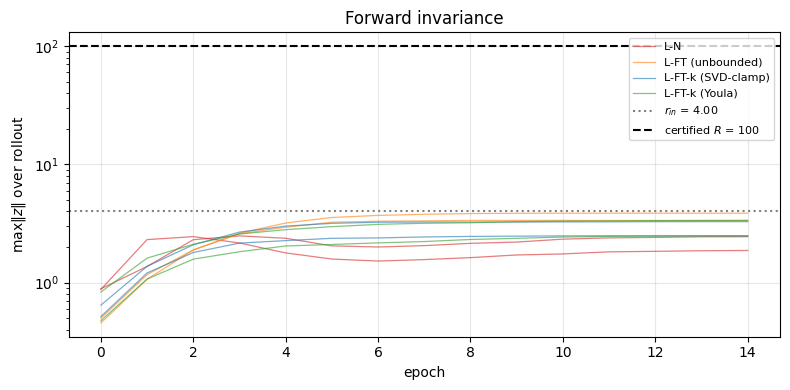

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
for name in NAMES:
    for si, h in enumerate(histories[name]):
        if h['zmax']:
            ax.plot(h['zmax'], color=COLOR[name], lw=0.9, alpha=0.6,
                    label=name if si == 0 else None)
ax.axhline(r_in, ls=':', c='gray', label=f'$r_{{in}}$ = {r_in:.2f}')
ax.axhline(budget.kappa_max * r_in, ls='--', c='k',
           label=f'certified $R$ = {budget.kappa_max * r_in:.0f}')
ax.set_yscale('log'); ax.set_xlabel('epoch'); ax.set_ylabel(r'$\max\|z\|$ over rollout')
ax.set_title('Forward invariance'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Precompute validation rollouts

One pass over the held-out set per model-seed, reused by D3/D4/D5/D7 below.

In [12]:
ROLL = {}
for name in NAMES:
    yh = np.full((len(list(SEEDS)), val.W.shape[0], train_cfg.L_eval + 1), np.nan, np.float32)
    zz = torch.full((len(list(SEEDS)), val.W.shape[0], train_cfg.L_eval + 1, budget.m), float('nan'))
    for si, mdl in enumerate(models[name]):
        with torch.no_grad():
            yhat, zs = rollout_y(mdl.eval(), val.W, val.U, train_cfg.L_eval, train_cfg.h)
        y = yhat.cpu().numpy()
        yh[si] = np.where(np.isfinite(y), y, np.nan); zz[si] = zs.cpu()
    ROLL[name] = {'yhat': yh, 'z': zz}

Yva_np  = val.Y.cpu().numpy()
tline_e = np.arange(train_cfg.L_eval + 1) * train_cfg.h
T_train = train_cfg.L * train_cfg.h
print('precomputed val rollouts for', list(ROLL))

precomputed val rollouts for ['L-N', 'L-FT (unbounded)', 'L-FT-k (SVD-clamp)', 'L-FT-k (Youla)']


## D3 -- reconstruction on a held-out trajectory

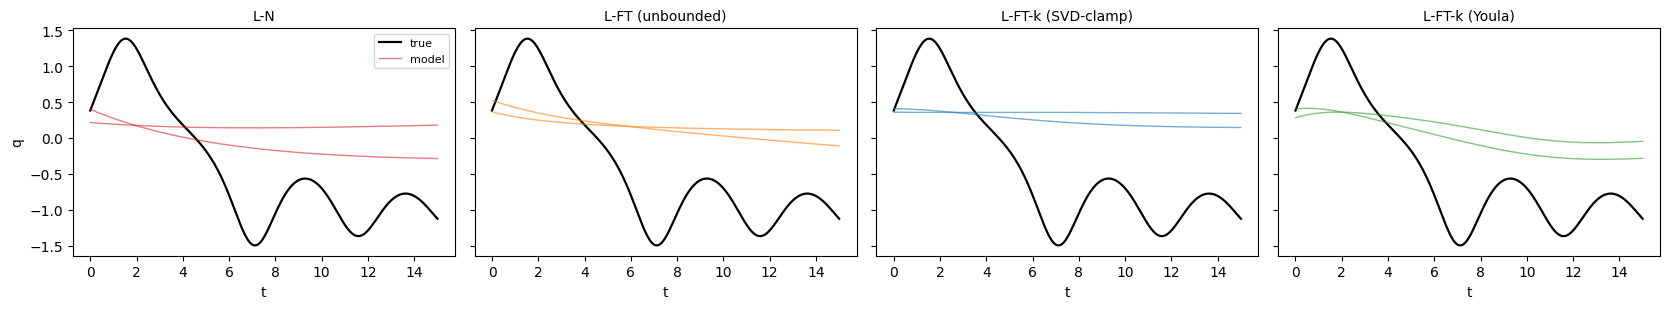

In [13]:
TRAJ = 0
t = np.arange(train_cfg.L_eval + 1) * train_cfg.h
fig, axes = plt.subplots(1, len(NAMES), figsize=(4.2 * len(NAMES), 3.2), sharey=True)
for ax, name in zip(np.atleast_1d(axes), NAMES):
    ax.plot(t, val.Y[TRAJ].cpu(), 'k', lw=1.6, label='true')
    for si, mdl in enumerate(models[name]):
        with torch.no_grad():
            yh, _ = rollout_y(mdl.eval(), val.W[TRAJ:TRAJ+1], val.U[TRAJ:TRAJ+1],
                              train_cfg.L_eval, train_cfg.h)
        ax.plot(t, yh[0].cpu(), color=COLOR[name], alpha=.6, lw=1,
                label='model' if si == 0 else None)
    ax.set_title(name, fontsize=10); ax.set_xlabel('t')
np.atleast_1d(axes)[0].set_ylabel('q'); np.atleast_1d(axes)[0].legend(fontsize=8)
fig.tight_layout(); plt.show()

## D4 -- per-horizon reconstruction MSE

Error as a function of how far past the training horizon the rollout has run.
The dashed line marks where training stopped; everything to its right is
extrapolation the model was never optimized for.

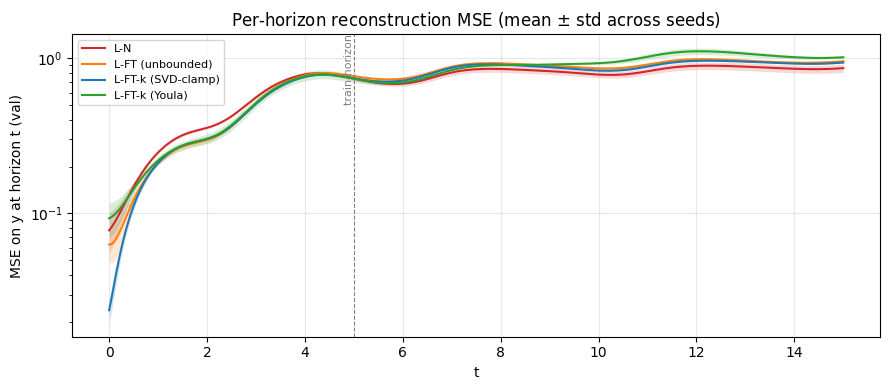

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
for name in NAMES:
    mse_t = np.nanmean((ROLL[name]['yhat'] - Yva_np[None]) ** 2, axis=1)
    mean, std = np.nanmean(mse_t, 0), np.nanstd(mse_t, 0)
    ax.semilogy(tline_e, np.maximum(mean, 1e-12), color=COLOR[name], lw=1.5, label=name)
    ax.fill_between(tline_e, np.maximum(mean - std, 1e-12), mean + std,
                    color=COLOR[name], alpha=0.18, lw=0)
ax.axvline(T_train, color='gray', lw=0.8, ls='--')
ax.annotate('train horizon', (T_train, ax.get_ylim()[1]), fontsize=8,
            ha='right', va='top', rotation=90, color='gray')
ax.set_xlabel('t'); ax.set_ylabel('MSE on y at horizon t (val)')
ax.set_title(r'Per-horizon reconstruction MSE (mean $\pm$ std across seeds)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## D5 -- implicit recovery of the hidden coordinate

**The most informative diagnostic here.** Only `q` is ever measured; `q_dot` is
never shown to the model at any point in training. Fitting a *linear* readout
from the latent state to each, on a held-out split, asks whether the encoder
inferred the velocity on its own from the measurement window.

`R^2 -> q` near 1 is expected -- that is the training signal. `R^2 -> q_dot` is
the real result: it measures whether the latent state is a genuine information
state for the plant rather than a curve-fit of the output.


> **Read this figure only with `QUICK = False`.** At the reduced preset the models
> are badly undertrained -- even `R^2 -> q`, the *observed* coordinate, comes out
> around 0.2, so the hidden-coordinate number is measuring nothing but lack of
> training. The frozen notebooks report `R^2 -> q_dot ~ 0.65` for the L-FT
> variants at 200 epochs. A near-zero value here is an artifact of the preset, not
> a property of the method.


Linear recoverability from the latent state (mean +/- std across seeds):
variant                    R2 -> q (observed)     R2 -> q_dot (HIDDEN)
L-N                          0.292 +/- 0.052           0.073 +/- 0.007
L-FT (unbounded)             0.193 +/- 0.019           0.092 +/- 0.005
L-FT-k (SVD-clamp)           0.209 +/- 0.007           0.070 +/- 0.012
L-FT-k (Youla)               0.145 +/- 0.041           0.077 +/- 0.006


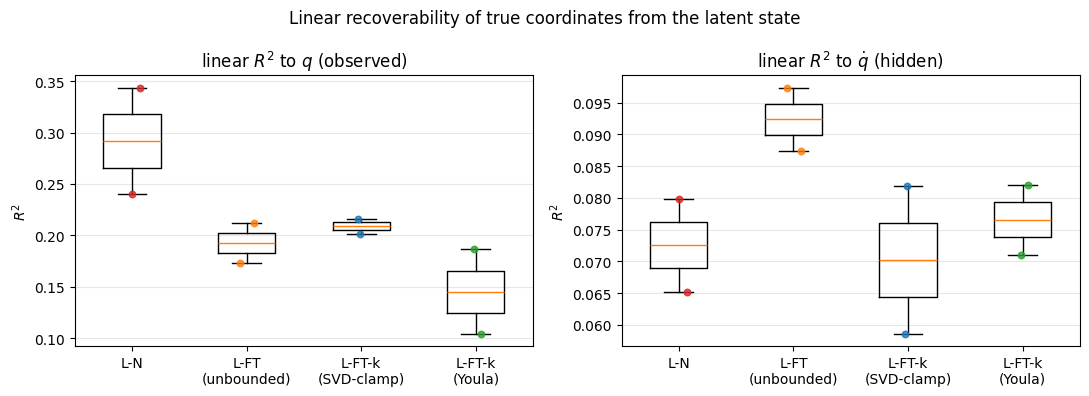

In [15]:
Xva  = val.Xfull
Q    = Xva[..., 0].numpy().reshape(-1)
Qdot = Xva[..., 1].numpy().reshape(-1)
perm = np.random.default_rng(7).permutation(Q.shape[0]); half = len(perm) // 2
fit_i, ev_i = perm[:half], perm[half:]

R2 = {n: {'q': [], 'qdot': []} for n in NAMES}
for name in NAMES:
    for si in range(len(list(SEEDS))):
        Z = ROLL[name]['z'][si].reshape(-1, budget.m).numpy()
        if not np.all(np.isfinite(Z)):
            R2[name]['q'].append(np.nan); R2[name]['qdot'].append(np.nan); continue
        R2[name]['q'].append(linear_recovery_r2(Z, Q, fit_i, ev_i))
        R2[name]['qdot'].append(linear_recovery_r2(Z, Qdot, fit_i, ev_i))

print('Linear recoverability from the latent state (mean +/- std across seeds):')
print(f'{"variant":22s} {"R2 -> q (observed)":>22s} {"R2 -> q_dot (HIDDEN)":>24s}')
for name in NAMES:
    q, qd = np.array(R2[name]['q']), np.array(R2[name]['qdot'])
    print(f'{name:22s} {np.nanmean(q):11.3f} +/- {np.nanstd(q):5.3f} '
          f'{np.nanmean(qd):15.3f} +/- {np.nanstd(qd):5.3f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, key, ttl in [(axes[0], 'q',    r'linear $R^2$ to $q$ (observed)'),
                     (axes[1], 'qdot', r'linear $R^2$ to $\dot q$ (hidden)')]:
    d = [np.array(R2[n][key], dtype=float) for n in NAMES]
    d = [x[np.isfinite(x)] for x in d]
    ax.boxplot(d, tick_labels=[n.replace(' ', chr(10)) for n in NAMES],
               showfliers=False, widths=0.5)
    rng = np.random.default_rng(1)
    for i, (name, x) in enumerate(zip(NAMES, d), start=1):
        ax.scatter(i + (rng.random(len(x)) - 0.5) * 0.15, x, s=22,
                   color=COLOR[name], alpha=0.8, zorder=3)
    ax.set_title(ttl); ax.set_ylabel(r'$R^2$'); ax.grid(alpha=0.3, axis='y')
fig.suptitle('Linear recoverability of true coordinates from the latent state')
plt.tight_layout(); plt.show()

## D6 / D7 -- phase portrait and latent-space geometry

Side by side: the plant's true phase portrait, then the learned latent
trajectories projected onto their first two principal components. The question
is whether the latent geometry reproduces the plant's structure -- two wells
around the sinks, separated by the saddle -- or folds into something that fits
the output without carrying the dynamics.

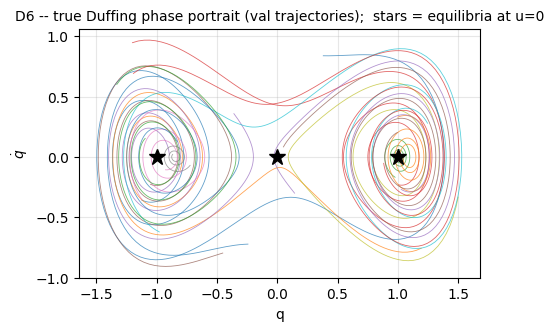

In [16]:
Xva_np = val.Xfull.numpy()
fig, ax = plt.subplots(figsize=(5, 5))
for i in range(min(16, Xva_np.shape[0])):
    ax.plot(Xva_np[i, :, 0], Xva_np[i, :, 1], lw=0.6, alpha=0.7)
for xe in equilibria(0.0):
    ax.plot(xe[0], xe[1], 'k*', ms=12)
ax.set_xlabel('q'); ax.set_ylabel(r'$\dot q$'); ax.set_aspect('equal')
ax.set_title('D6 -- true Duffing phase portrait (val trajectories);  stars = equilibria at u=0', fontsize=10)
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

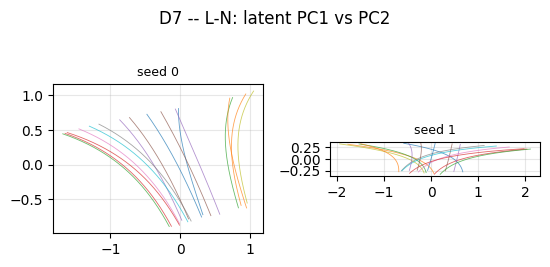

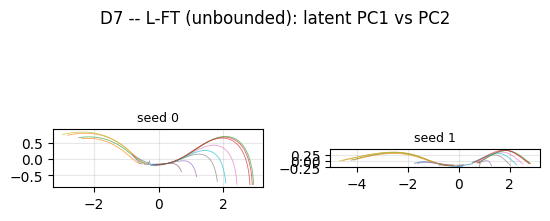

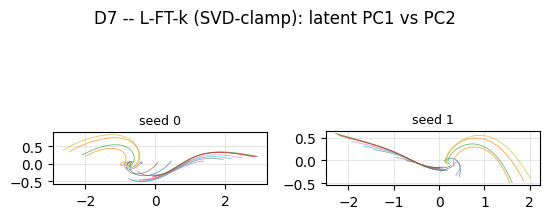

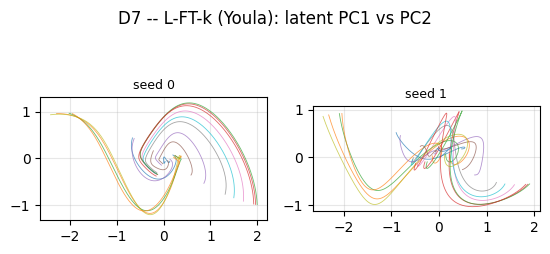

In [17]:
for name in NAMES:
    fig, axes = seed_grid(len(list(SEEDS)), ncols=5, panel=(2.8, 2.6))
    for si, seed in enumerate(SEEDS):
        ax = axes[si]
        Z = ROLL[name]['z'][si].numpy(); Zf = Z.reshape(-1, Z.shape[-1])
        if not np.all(np.isfinite(Zf)):
            ax.set_title(f'seed {seed}: diverged', fontsize=8); continue
        proj, _ = pca_2d(Zf)
        proj = proj.reshape(Z.shape[0], Z.shape[1], 2)
        for i in range(min(16, Z.shape[0])):
            ax.plot(proj[i, :, 0], proj[i, :, 1], lw=0.6, alpha=0.7)
        ax.set_title(f'seed {seed}', fontsize=9); ax.set_aspect('equal'); ax.grid(alpha=0.3)
    fig.suptitle(f'D7 -- {name}: latent PC1 vs PC2', y=1.01)
    plt.tight_layout(); plt.show()

## D8 -- spectrum in the complex plane

The structured variants expose `A(z)` directly. `L-N` has no such object, so its
linearization has to be differentiated out -- that asymmetry is exactly what the
structural prior buys.

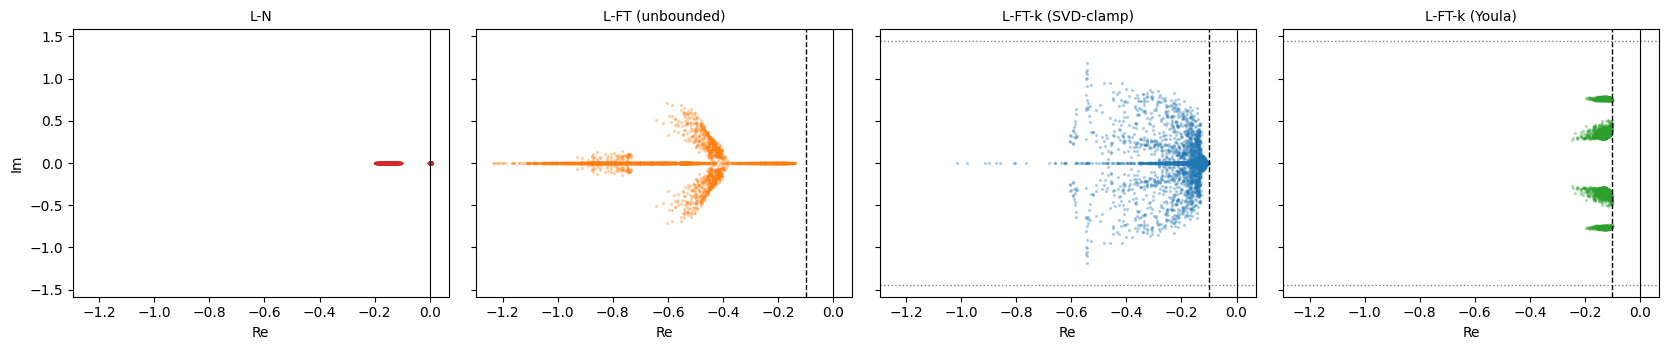

In [18]:
Ubox = torch.zeros(Zbox.shape[0], device=device)
fig, axes = plt.subplots(1, len(NAMES), figsize=(4.2 * len(NAMES), 3.6), sharex=True, sharey=True)
for ax, name in zip(np.atleast_1d(axes), NAMES):
    dyn = models[name][0].dynamics.eval()
    if hasattr(dyn, 'A'):
        ev = eigvals_A(dyn, Zbox[:1000], budget.m)
        ax.axvline(-budget.sigma_min, ls='--', c='k', lw=1)
        if hasattr(dyn, 'c_K'):
            for s in (+1, -1):
                ax.axhline(s * dyn.c_K, ls=':', c='gray', lw=1)
    else:
        ev = eig_field_jac(dyn, Zbox[:1000], Ubox[:1000], budget.m)
    ax.scatter(ev.real.ravel(), ev.imag.ravel(), s=2, alpha=.25, color=COLOR[name])
    ax.axvline(0, c='k', lw=.8)
    ax.set_title(name, fontsize=10); ax.set_xlabel('Re')
np.atleast_1d(axes)[0].set_ylabel('Im')
fig.tight_layout(); plt.show()

## D9 -- decoded equilibrium map vs the true pitchfork

Decode the image of the learned `g` and overlay the plant's true equilibrium
branches. `g` is where the FT split puts the equilibria, so this asks directly
whether identification recovered the bifurcation structure -- both stable
branches and the saddle between them -- from output data alone.

Also checks the box bound: `g = R_g * tanh(...)` forces `|g|_inf <= R_g` by
construction.

Equilibrium-map bound check, |g|_inf <= R_g = 2.00:
  L-FT (unbounded)       max |g|_inf = 1.283   ok=True
  L-FT-k (SVD-clamp)     max |g|_inf = 1.310   ok=True
  L-FT-k (Youla)         max |g|_inf = 1.146   ok=True


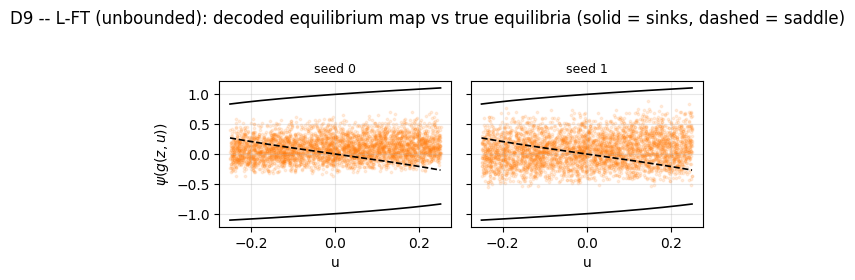

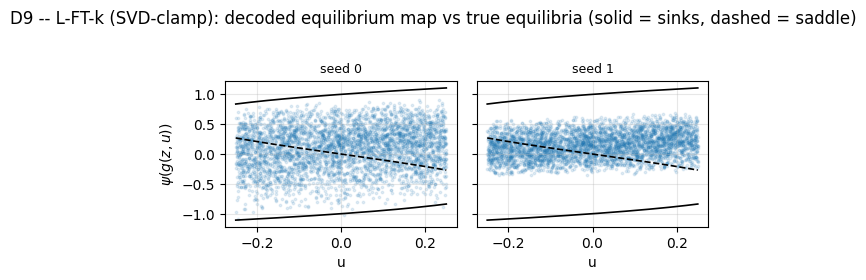

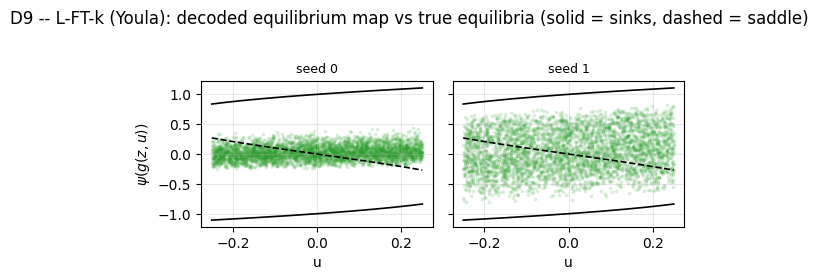

In [19]:
gen = torch.Generator().manual_seed(0)
Z_box = ((2 * torch.rand(4000, budget.m, generator=gen) - 1) * model_cfg.equilibrium.R_g).to(device)
U_box = ((2 * torch.rand(4000, generator=gen) - 1) * data_tr.u_range).to(device)
u_grid = np.linspace(-data_tr.u_range, data_tr.u_range, 200)
branches = np.array([[e[0] for e in equilibria(u)] for u in u_grid])   # (200, 3)

print(f'Equilibrium-map bound check, |g|_inf <= R_g = {model_cfg.equilibrium.R_g:.2f}:')
for name in FT_NAMES:
    mx = np.array([g_image(m.dynamics, Z_box, U_box).abs().max().item() for m in models[name]])
    print(f'  {name:22s} max |g|_inf = {mx.max():.3f}   ok={bool((mx <= model_cfg.equilibrium.R_g + 1e-4).all())}')

U_np = U_box.cpu().numpy()
for name in FT_NAMES:
    fig, axes = seed_grid(len(list(SEEDS)), ncols=5, panel=(2.9, 2.7), sharex=True, sharey=True)
    for si, seed in enumerate(SEEDS):
        ax = axes[si]
        Gb = g_image(models[name][si].dynamics, Z_box, U_box)
        qg = models[name][si].decode(Gb).detach().cpu().numpy()
        ax.scatter(U_np, qg, s=3, alpha=0.12, color=COLOR[name])
        ax.plot(u_grid, branches[:, 0], 'k-',  lw=1.2)
        ax.plot(u_grid, branches[:, 2], 'k-',  lw=1.2)
        ax.plot(u_grid, branches[:, 1], 'k--', lw=1.2)
        ax.set_title(f'seed {seed}', fontsize=9); ax.set_xlabel('u'); ax.grid(alpha=0.3)
    axes[0].set_ylabel(r'$\psi(g(z,u))$')
    fig.suptitle(f'D9 -- {name}: decoded equilibrium map vs true equilibria '
                 '(solid = sinks, dashed = saddle)', y=1.02)
    plt.tight_layout(); plt.show()

## Takeaway

**The constraint binds.** After training, `L-FT (unbounded)` drifts past
`kappa_max` while both bounded variants stay under it at every seed. Same
stability structure, same residual regularizer -- the only difference is whether
the skew part is capped. No penalty term is doing this work: the
parameterization cannot express a violating operator, so the bound holds at
initialization, at every intermediate step, and at convergence.

**The Youla route reaches the cap without an SVD.** It gets there through
`Q Sigma Q^T` with `Q = matrix_exp(W - W^T)`, whose singular values are doubled
by construction -- which is what makes it usable in the control stage, where
`spectral_clamp`'s backward is ill-conditioned on skew arguments and its forward
SVD outright fails to converge.

Under the `QUICK` preset the *accuracy* numbers are not meaningful -- 15 epochs
on 128 trajectories separates nothing, and the variants land on top of each
other. Flip `QUICK = False`, or read the frozen notebooks named at the top, for
the 10-seed accuracy and recovery comparison.